# 01 · KNN do Zero

Implementação das duas versões do KNN vistas no slide **"Pausa para Código"** do Bloco 4:

1. Distância euclidiana
2. Votação majoritária
3. Ponderado por distância
4. Comparação visual das fronteiras de decisão
5. Checagem de sanidade contra o `KNeighborsClassifier` do scikit-learn


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
import matplotlib.pyplot as plt

from distance_models import (
    euclidean_distance,
    knn_majority_predict_one,
    knn_weighted_predict_one,
    KNNClassifier,
)
from datasets_utils import load_classification_dataset, to_2d
from viz import plot_decision_boundary, plot_weighted_scatter

plt.rcParams['figure.facecolor'] = 'white'
np.random.seed(42)

## 1. Distância euclidiana

$$d(x, x_i) = \sqrt{\sum_j (x_j - x_{ij})^2}$$

In [2]:
a = np.array([1.0, 2.0])
b = np.array([4.0, 6.0])
print('distância entre', a, 'e', b, '=', euclidean_distance(a, b))

distância entre [1. 2.] e [4. 6.] = 5.0


## 2. Carregando um dataset (Iris, reduzido a 2D para poder visualizar)

Usamos as duas primeiras features originais (comprimento/largura da sépala) — mais fácil de explicar ao vivo do que uma projeção PCA.

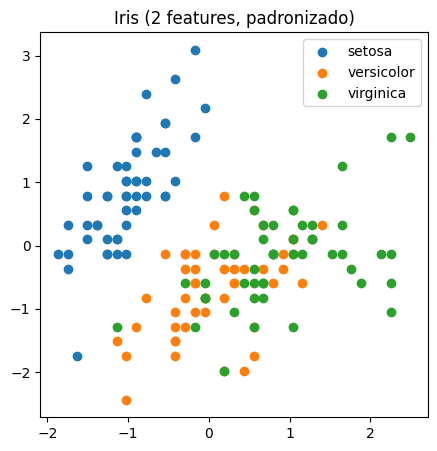

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data[:, :2]  # só 2 features, pra dar pra plotar
y = iris.target

from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

plt.figure(figsize=(5, 5))
for c in np.unique(y):
    plt.scatter(X[y == c, 0], X[y == c, 1], label=iris.target_names[c])
plt.legend(); plt.title('Iris (2 features, padronizado)')
plt.show()

## 3. Votação majoritária — função ponto a ponto

Exatamente a função que aparece no slide de "pausa para código".

In [4]:
x_query = np.array([0.0, 0.0])  # um ponto qualquer no meio do espaço
k = 5

pred_majority = knn_majority_predict_one(X, y, x_query, k)
print(f'Previsão (majoritário, k={k}):', iris.target_names[pred_majority])

Previsão (majoritário, k=5): versicolor


## 4. Ponderado por distância — função ponto a ponto

In [5]:
pred_weighted = knn_weighted_predict_one(X, y, x_query, k, p=1)
print(f'Previsão (ponderado, k={k}):', iris.target_names[pred_weighted])

Previsão (ponderado, k=5): versicolor


## 5. Visualizando o efeito do peso: tamanho do ponto ∝ peso do voto

Isso é a mesma ideia do slide 8 ("Ponderado por Distância") — só que agora com dados reais, não um desenho ilustrativo.

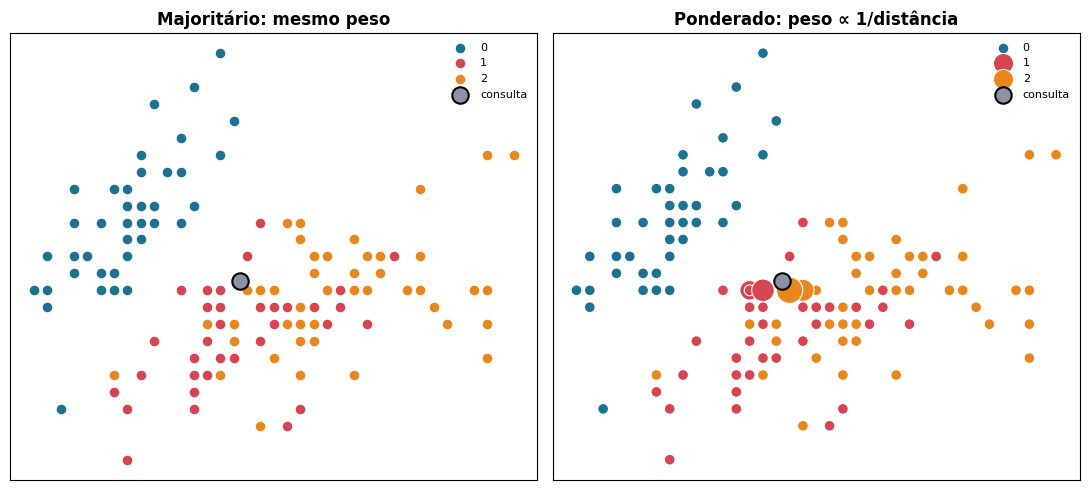

In [6]:
dist = np.array([euclidean_distance(x_query, xi) for xi in X])
idx_k = np.argsort(dist)[:k]
pesos_todos = np.zeros(len(X))
pesos_todos[idx_k] = 1.0 / (dist[idx_k] + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_weighted_scatter(X, y, x_query, k, weights=None, ax=axes[0], title='Majoritário: mesmo peso')
plot_weighted_scatter(X, y, x_query, k, weights=pesos_todos, ax=axes[1], title='Ponderado: peso ∝ 1/distância')
plt.tight_layout(); plt.show()

## 6. Fronteiras de decisão: majoritário vs. ponderado, para diferentes k

Aqui usamos a versão vetorizada (`KNNClassifier`, em `src/distance_models.py`) só porque é mais rápida para
avaliar milhares de pontos da grade — a lógica é idêntica à das funções acima.

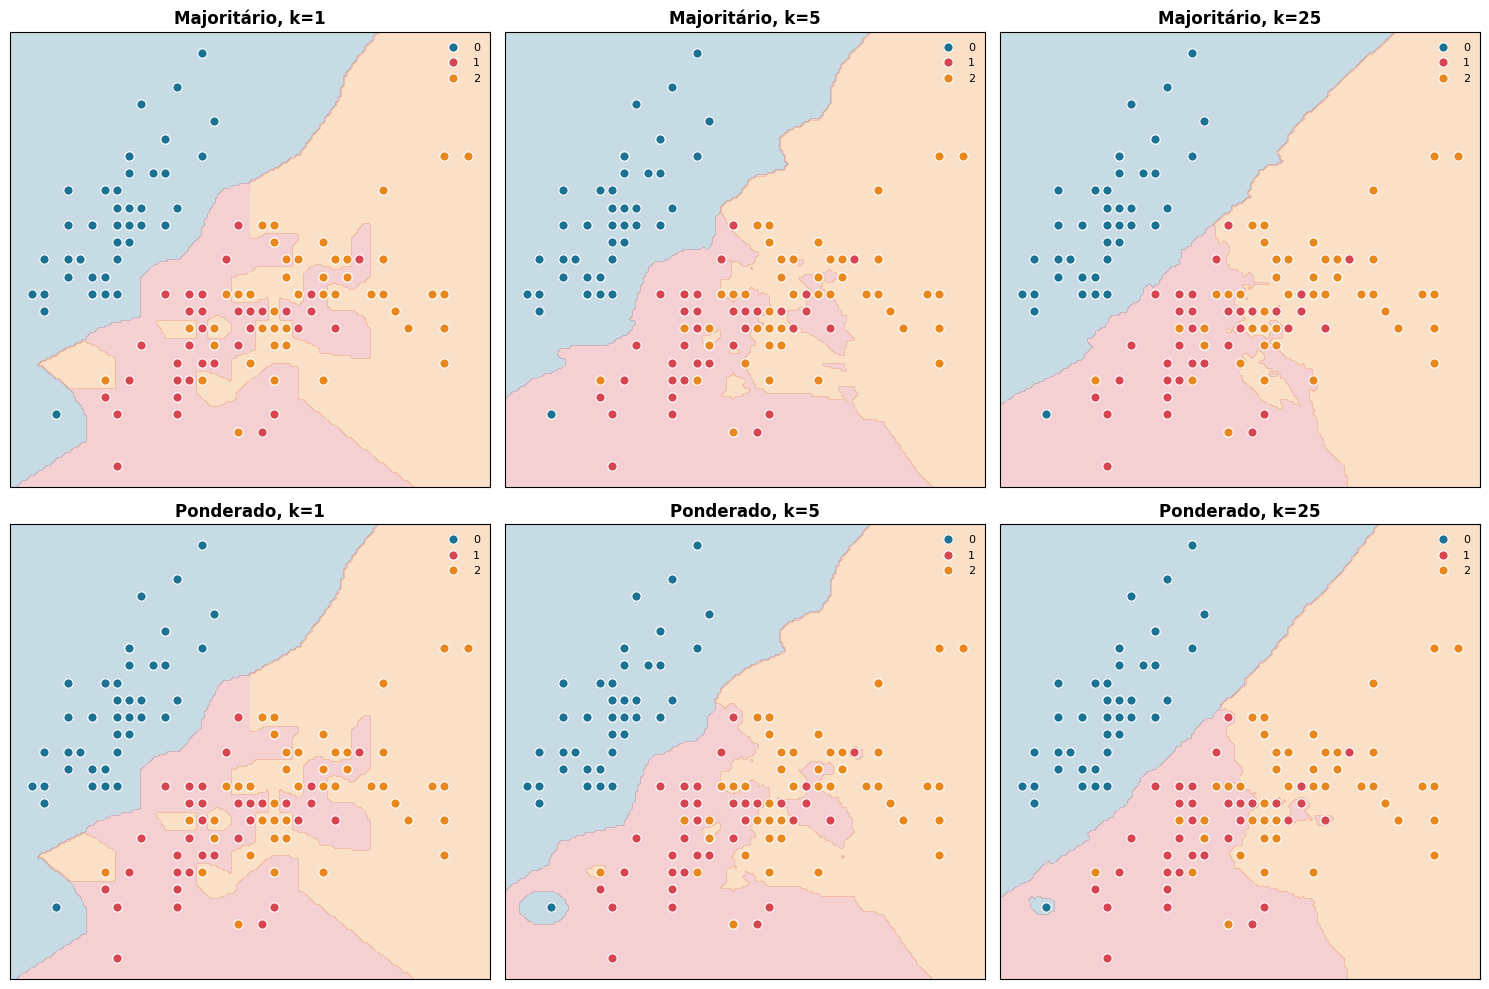

Repare: com k grande, o majoritário fica bem mais "borrado" que o ponderado — os vizinhos distantes pesam cada vez menos no ponderado.


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
ks = [1, 5, 25]
for col, k in enumerate(ks):
    plot_decision_boundary(KNNClassifier(k=k, weighting='majority'), X, y, ax=axes[0, col], title=f'Majoritário, k={k}')
    plot_decision_boundary(KNNClassifier(k=k, weighting='distance'), X, y, ax=axes[1, col], title=f'Ponderado, k={k}')
plt.tight_layout(); plt.show()
print('Repare: com k grande, o majoritário fica bem mais "borrado" que o ponderado — os vizinhos distantes pesam cada vez menos no ponderado.')

## 7. Checagem de sanidade: nossa implementação bate com o scikit-learn?

Comparamos a acurácia do nosso `KNNClassifier` com o `KNeighborsClassifier` oficial, no mesmo split, mesmo k.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

for weighting, sk_weights in [('majority', 'uniform'), ('distance', 'distance')]:
    nosso = KNNClassifier(k=5, weighting=weighting).fit(X_train, y_train)
    oficial = KNeighborsClassifier(n_neighbors=5, weights=sk_weights).fit(X_train, y_train)
    acc_nosso = (nosso.predict(X_test) == y_test).mean()
    acc_oficial = (oficial.predict(X_test) == y_test).mean()
    print(f'{weighting:10s} | nosso: {acc_nosso:.4f}  |  sklearn: {acc_oficial:.4f}')

majority   | nosso: 0.7556  |  sklearn: 0.7556
distance   | nosso: 0.6667  |  sklearn: 0.6444


---
**Pronto para o FEMa:** o `KNNClassifier` acima já segue o padrão `BaseEstimator` do scikit-learn (`fit`/`predict`/`predict_proba`). Quando o `FEMaClassifier` existir (ver esqueleto no final de `src/distance_models.py`), basta importar e chamar `plot_decision_boundary(FEMaClassifier(...), X, y)` — tudo o que foi construído aqui já funciona.